#### Import libraries and load data

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk

# Set plotting style
sns.set_theme(style="whitegrid")

langs = ['eng', 'zho', 'nld']
datasets = {}

# Load data from the directory we just downloaded to
for lang in langs:
    path = f"../data/raw/{lang}_dataset"
    if os.path.exists(path):
        datasets[lang] = load_from_disk(path)
        print(f"Loaded {lang}: {datasets[lang]['train'].num_rows} documents.")
    else:
        print(f"Path not found: {path}")

Loaded eng: 137710 documents.
Loaded zho: 203891 documents.
Loaded nld: 304611 documents.


#### Extract features and compute statistics 

In [ ]:
# To speed up computation, we randomly sample 10,000 rows from each language for EDA
sample_size = 10000
data_stats = []

for lang, ds in datasets.items():
    # Get the training set and sample
    train_split = ds['train']
    actual_sample_size = min(sample_size, len(train_split))
    sampled_data = train_split.shuffle(seed=42).select(range(actual_sample_size))
    
    for item in sampled_data:
        text = item['text']
        # Simple calculation of character length and rough word count 
        # (characters for ZH, space-separated words for EN/NL)
        char_length = len(text)
        word_count = len(text.split()) if lang != 'zh' else char_length
        
        data_stats.append({
            'Language': lang.upper(),
            'Character Length': char_length,
            'Rough Word Count': word_count
        })

df_stats = pd.DataFrame(data_stats)
display(df_stats.groupby('Language').describe())

Character Length                                               \
                    count       mean           std   min    25%    50%   
Language                                                                 
ENG               10000.0  3819.7640  21583.594051  11.0  178.0  389.0   
NLD               10000.0  2139.0952  22465.853461  17.0  143.0  285.0   
ZHO               10000.0   944.5255   2002.021669   3.0   57.0  302.0   

                             Rough Word Count                              \
              75%        max            count      mean          std  min   
Language                                                                    
ENG       1026.25   744455.0          10000.0  700.2680  3970.596766  3.0   
NLD        521.00  2049911.0          10000.0  409.7520  3637.444628  2.0   
ZHO        724.00    65618.0          10000.0   77.9278   259.318752  1.0   

                                       
           25%   50%    75%       max  
Language                               
ENG       30.0  66.0  173.0  133589.0  
NLD       25.0  50.0   90.0  317894.0  
ZHO        1.0  10.0   23.0    9676.0

#### Visualize length distribution

/var/folders/zm/s3nl0q4959v39_q9fkwm3xvw0000gn/T/ipykernel_93258/4180826010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_stats, x='Language', y='Character Length', palette="Set2")


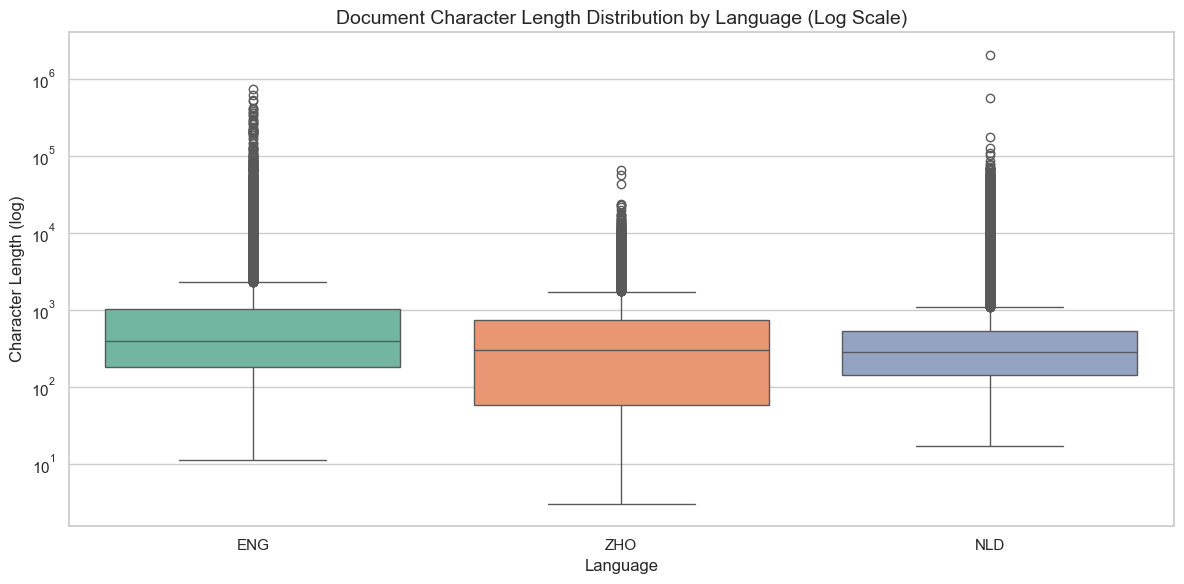

In [3]:
plt.figure(figsize=(12, 6))

# Use a logarithmic scale for character length distribution to handle outliers
sns.boxplot(data=df_stats, x='Language', y='Character Length', palette="Set2")
plt.title("Document Character Length Distribution by Language (Log Scale)", fontsize=14)
plt.yscale('log')
plt.ylabel("Character Length (log)", fontsize=12)
plt.xlabel("Language", fontsize=12)

plt.tight_layout()
plt.show()

#### Inspect the mixed data

In [116]:
import pandas as pd
from datasets import load_from_disk

# Load the Stage 1 data we just mixed
# (假設我們跑的是 10M 測試預算)
stage1_path = "../data/processed_10M/Stage_1_Foundation"
mixed_ds = load_from_disk(stage1_path)

print(f"Total Rows: {len(mixed_ds):,}")

# Convert the first 10 rows to a Pandas DataFrame for easy viewing
df_preview = pd.DataFrame(mixed_ds['train'].select(range(10)))

# Display the preview
#print("\n--- Data Preview ---")
#display(df_preview)

# Verify if the mixing ratio meets expectations
print("\n--- Row Count by Language ---")
# 注意：這裡是 Row 數量比例，不是 Token 比例。
# 因為英文單字佔的 Row 通常比中文長，所以 Row 比例不會剛好等於 50:25:25，這是正常的！
df_all = pd.DataFrame(mixed_ds['train'])
display(df_all['language'].value_counts(normalize=True).round(4) * 100)

Total Rows: 2

--- Row Count by Language ---


language
nld    36.97
eng    36.80
zho    26.23
Name: proportion, dtype: float64

#### Qualitative Tokenizer Check

In [ ]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("../tokenizers/tokenizer_10M_16k.json")


# Define some "difficult/high-frequency" test sentences for the three languages
test_sentences = {
    "ENG": [
        "Language modeling is a fascinating subfield of artificial intelligence.",
        "The quick brown fox jumps over the lazy dog.",
        "Unbelievable architectural optimization techniques." # 測試字首字尾拆解
    ],
    "ZHO": [
        "因为我们有强大的计算资源，所以模型训练速度非常快。", # 測試常見連接詞
        "自然语言处理是一个充满挑战的领域。", # 測試專有名詞
        "这是一个不合理的超参数设定。" # 測試否定詞與專有名詞
    ],
    "NLD": [
        "Natuurlijke taalverwerking is een fascinerend deelgebied van kunstmatige intelligentie.",
        "De snelle bruine vos springt over de luie hond.",
        "Onwaarschijnlijke architectonische optimalisatietechnieken."
    ]
}

print("=== Tokenizer Qualitative Check ===\n")

for lang, sentences in test_sentences.items():
    print(f"--- {lang} ---")
    for text in sentences:
        encoded = tokenizer.encode(text)
        

        # Key modification: Do not print encoded.tokens. Decode each ID back to text individually.
        readable_tokens = []
        for token_id in encoded.ids:
            # decode 會把 ID 轉回原本的 UTF-8 詞彙
            decoded_word = tokenizer.decode([token_id])
            
            # 清理一下空白，讓排版更好看
            clean_word = decoded_word.strip()
            if not clean_word:
                clean_word = "_" # 代表空白 token
            readable_tokens.append(clean_word)
        
        print(f"Original : {text}")
        print(f"Tokens   : {' | '.join(readable_tokens)}")
        print(f"Count    : {len(encoded.ids)} tokens")
        print("-" * 40)
    print("\n")

=== Tokenizer Qualitative Check ===

--- ENG ---
Original : Language modeling is a fascinating subfield of artificial intelligence.
Tokens   : L | ang | uage | mod | eling | is | a | fasc | in | ating | sub | field | of | art | ific | ial | intelligence | .
Count    : 18 tokens
----------------------------------------
Original : The quick brown fox jumps over the lazy dog.
Tokens   : The | quick | brown | fox | jumps | over | the | lazy | dog | .
Count    : 10 tokens
----------------------------------------
Original : Unbelievable architectural optimization techniques.
Tokens   : Un | bel | iev | able | architect | ural | opt | im | ization | techn | iqu | es | .
Count    : 13 tokens
----------------------------------------


--- ZHO ---
Original : 因为我们有强大的计算资源，所以模型训练速度非常快。
Tokens   : 因为 | 我们 | 有 | 强 | 大的 | 计 | 算 | 资 | 源 | _ | 所以 | � | � | � | � | 训 | 练 | � | � | 度 | 非常 | 快 | _
Count    : 23 tokens
----------------------------------------
Original : 自然语言处理是一个充满挑战的领域。
Tokens   : 自 | 然 |

#### Evaluation Tokenizer

In [1]:
import os
import logging
from datasets import load_from_disk
from tokenizers import Tokenizer

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def calculate_fertility(tokenizer_path, sample_size=1000):
    if not os.path.exists(tokenizer_path):
        logging.error(f"找不到 Tokenizer 檔案 (Tokenizer file not found): {tokenizer_path}")
        return

    tokenizer = Tokenizer.from_file(tokenizer_path)
    langs = ['eng', 'zho', 'nld']
    
    logging.info(f"評估 Tokenizer (Evaluating Tokenizer): {tokenizer_path}")
    logging.info(f"樣本數 (Sample size): {sample_size} 筆/語言 (docs/lang)\n")
    
    for lang in langs:
        try:
            # 載入原始資料集 (Load raw datasets)
            raw_ds = load_from_disk(f"../data/raw/{lang}_dataset")
            # 隨機打亂並抽取樣本 (Shuffle and select sample)
            sample_ds = raw_ds['train'].shuffle(seed=42).select(range(sample_size))
        except Exception as e:
            logging.warning(f"無法載入 {lang} 資料集 (Failed to load {lang} dataset): {e}")
            continue

        total_tokens = 0
        total_words = 0
        total_chars = 0
        
        for item in sample_ds:
            text = item['text']
            if not text.strip(): 
                continue
            
            # 計算 Token 數量 (Calculate token count)
            encoded = tokenizer.encode(text)
            total_tokens += len(encoded.ids)
            
            # 計算字數與字元數 (Calculate word and character counts)
            total_words += len(text.split())
            total_chars += len(text.replace(" ", ""))

        # 輸出統計結果 (Output statistics)
        print(f"=== 語言 (Language): {lang.upper()} ===")
        print(f"總 Token 數 (Total Tokens): {total_tokens:,}")
        
        if lang == 'zho':
            # 中文以「字元」為單位計算生育率 (For Chinese, calculate fertility per character)
            fertility_rate = total_tokens / max(1, total_chars)
            print(f"總字元數 (Total Characters): {total_chars:,}")
            print(f"👶 生育率 (Tokens / Character): {fertility_rate:.3f}")
            
            if fertility_rate > 1.8:
                print("⚠️ 警告 (WARNING): 中文被切得太碎了！一個中文字平均被切成快 2 個以上的 Byte Tokens。")
                print("   建議 (Action): 提高 train_tokenizer.py 中 'zho' 的抽樣預算 (預設是 500k)。")
            elif fertility_rate < 1.0:
                print("✅ 狀態 (Status): 極佳！(Excellent!) 幾乎每個中文字都完整對應一個 Token。")
            else:
                print("✅ 狀態 (Status): 正常範圍內。(Within normal range.)")
                
        else:
            # 英文與荷蘭文以「單字」為單位計算生育率 (For Eng/Nld, calculate fertility per word)
            fertility_rate = total_tokens / max(1, total_words)
            print(f"總單字數 (Total Words): {total_words:,}")
            print(f"👶 生育率 (Tokens / Word): {fertility_rate:.3f}")
            
            if fertility_rate > 1.8:
                print(f"⚠️ 警告 (WARNING): {lang} 單字被過度拆分！")
            else:
                print("✅ 狀態 (Status): 正常範圍內。(Within normal range.)")
        
        print("-" * 50)

if __name__ == "__main__":
    # 測試你 10M 預算的 16k tokenizer
    calculate_fertility("../tokenizers/tokenizer_10M_16k.json")

2026-05-20 15:46:35,266 - INFO - 評估 Tokenizer (Evaluating Tokenizer): ../tokenizers/tokenizer_10M_16k.json
2026-05-20 15:46:35,267 - INFO - 樣本數 (Sample size): 1000 筆/語言 (docs/lang)



=== 語言 (Language): ENG ===
總 Token 數 (Total Tokens): 1,003,203
總單字數 (Total Words): 591,002
👶 生育率 (Tokens / Word): 1.697
✅ 狀態 (Status): 正常範圍內。(Within normal range.)
--------------------------------------------------
=== 語言 (Language): ZHO ===
總 Token 數 (Total Tokens): 850,161
總字元數 (Total Characters): 833,512
👶 生育率 (Tokens / Character): 1.020
✅ 狀態 (Status): 正常範圍內。(Within normal range.)
--------------------------------------------------
=== 語言 (Language): NLD ===
總 Token 數 (Total Tokens): 1,127,031
總單字數 (Total Words): 739,427
👶 生育率 (Tokens / Word): 1.524
✅ 狀態 (Status): 正常範圍內。(Within normal range.)
--------------------------------------------------


✅ Tokenizer load success! Vocab size: 16,000
loading test samples...


,Language,Total Base Units,Total Tokens,Fertility (Tokens/Unit),UNK Rate (%)
0,eng,7002680,11773757,1.681322,0.0
1,nld,4097520,6159429,1.503209,0.0
2,zho,9445255,8857904,0.937815,0.0


/tmp/ipykernel_2542164/1394567464.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Language", y="Fertility (Tokens/Unit)", data=df_results, palette="viridis")


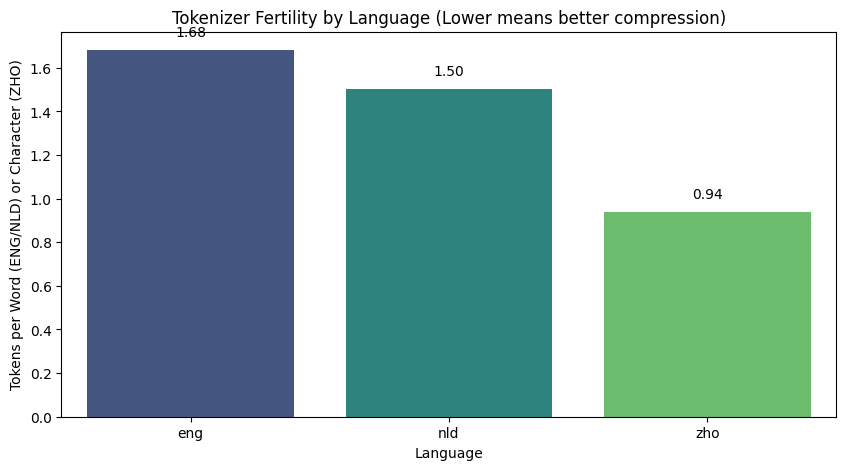


========== Byte Premium Alignment Check ==========
[ENG] relative ratio: 1.0000 | official Byte Premium: 1.0000 | difference: 0.0000
[NLD] relative ratio: 0.5231 | official Byte Premium: 1.0516 | difference: 0.5285
  -> ⚠️ warning: nld has a significant deviation from the official Byte Premium, consider adjusting training data ratio or BPE algorithm.
[ZHO] relative ratio: 0.7523 | official Byte Premium: 0.9894 | difference: 0.2371
  -> ⚠️ warning: zho has a significant deviation from the official Byte Premium, consider adjusting training data ratio or BPE algorithm.


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
from transformers import PreTrainedTokenizerFast

# 1. load Tokenizer
tokenizer_path = "../tokenizers/tokenizer_10M_16k.json"
try:
    tokenizer = PreTrainedTokenizerFast(
        tokenizer_file=tokenizer_path,
        unk_token="<unk>",
        bos_token="<s>",
        eos_token="</s>",
        pad_token="<pad>",
        mask_token="<mask>"
    )
    print(f"✅ Tokenizer load success! Vocab size: {tokenizer.vocab_size:,}")
except Exception as e:
    print(f"❌ Error loading tokenizer: {e}")

# 2. prepare test data (randomly sample 10,000 texts from each language's raw dataset)
langs = ['eng', 'nld', 'zho']
sample_size = 10000
texts = {}

print("loading test samples...")
for lang in langs:
    ds_path = f"../data/raw/{lang}_dataset"
    if os.path.exists(ds_path):
        ds = load_from_disk(ds_path)
        # randomly sample texts from the training split, ensuring evaluation is not biased by data order
        texts[lang] = ds['train'].shuffle(seed=42).select(range(sample_size))['text']
    else:
        print(f"找不到資料集: {ds_path}")

# 3. key evaluation function to compute fertility and UNK rate
def evaluate_tokenizer(tokenizer, texts, lang):
    total_words_or_chars = 0
    total_tokens = 0
    unk_count = 0
    
    for text in texts:
        # count words for ENG/NLD, characters for ZHO
        if lang == 'zho':
            total_words_or_chars += len(text)
        else:
            total_words_or_chars += len(text.split())
            
        # execute Tokenize
        encoded_ids = tokenizer.encode(text)
        total_tokens += len(encoded_ids)
        unk_count += encoded_ids.count(tokenizer.unk_token_id)
        
    # Fertility (each base unit is split into how many tokens, lower is better compression)
    fertility = total_tokens / total_words_or_chars if total_words_or_chars > 0 else 0
    # UNK Rate (unknown token ratio)
    unk_rate = (unk_count / total_tokens) * 100 if total_tokens > 0 else 0
    
    return {
        "Language": lang,
        "Total Base Units": total_words_or_chars,
        "Total Tokens": total_tokens,
        "Fertility (Tokens/Unit)": fertility,
        "UNK Rate (%)": unk_rate
    }

# 4. compute evaluation metrics for each language and compile results into a DataFrame
results = []
for lang in langs:
    if lang in texts:
        res = evaluate_tokenizer(tokenizer, texts[lang], lang)
        results.append(res)
        
df_results = pd.DataFrame(results)
display(df_results)

# 5. visualize fertility results
plt.figure(figsize=(10, 5))
sns.barplot(x="Language", y="Fertility (Tokens/Unit)", data=df_results, palette="viridis")
plt.title("Tokenizer Fertility by Language (Lower means better compression)")
plt.ylabel("Tokens per Word (ENG/NLD) or Character (ZHO)")
for index, value in enumerate(df_results["Fertility (Tokens/Unit)"]):
    plt.text(index, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
plt.show()

# 6. examine Byte Premium Alignment
official_premiums = {'eng': 1.0, 'nld': 1.0516, 'zho': 0.9894}

print("\n========== Byte Premium Alignment Check ==========")
try:
    eng_tokens = df_results[df_results['Language'] == 'eng']['Total Tokens'].values[0]
    
    for lang in langs:
        actual_tokens = df_results[df_results['Language'] == lang]['Total Tokens'].values[0]
        # 假設以英文的 Token 總數為基準 (1.0)，觀察其他語言的相對 Token 消耗量
        relative_ratio = actual_tokens / eng_tokens
        official_ratio = official_premiums[lang]
        diff = abs(relative_ratio - official_ratio)
        
        print(f"[{lang.upper()}] relative ratio: {relative_ratio:.4f} | official Byte Premium: {official_ratio:.4f} | difference: {diff:.4f}")
        if diff > 0.15:
            print(f"  -> ⚠️ warning: {lang} has a significant deviation from the official Byte Premium, consider adjusting training data ratio or BPE algorithm.")
except Exception as e:
    print("need English data to perform Byte Premium comparison.")

#### Analyze Encoding Efficiency

In [5]:
import pandas as pd
from datasets import load_from_disk
from tokenizers import Tokenizer

# Load the newly trained Tokenizer
tokenizer = Tokenizer.from_file("../tokenizers/tokenizer_10M_16k.json")
langs = ['eng', 'zho', 'nld']

efficiency_data = []

for lang in langs:
    # Load a small subset from the raw dataset to test
    ds = load_from_disk(f"../data/raw/{lang}_dataset")['train'].select(range(5000))
    
    total_chars = 0
    total_words = 0
    total_tokens = 0
    
    for item in ds:
        text = item['text']
        total_chars += len(text)
        total_words += len(text.split()) if lang != 'zho' else len(text) # 中文無空白分詞
        
        # Encode precisely using our Tokenizer
        encoded = tokenizer.encode(text)
        total_tokens += len(encoded.ids)
        
    efficiency_data.append({
        "Language": lang.upper(),
        "Tokens per Character": total_tokens / total_chars,
        "Tokens per Word (Approx)": total_tokens / total_words
    })

df_eff = pd.DataFrame(efficiency_data)
print("\n=== Encoding Efficiency Analysis ===")
display(df_eff)


=== Encoding Efficiency Analysis ===


,Language,Tokens per Character,Tokens per Word (Approx)
0,ENG,0.282901,1.519921
1,ZHO,1.088578,1.088578
2,NLD,0.285024,1.580309


#### Overview what sentences in dataset

In [ ]:
import os
import pandas as pd
from datasets import load_from_disk, DatasetDict, Dataset
from IPython.display import display, HTML

# 1. set dataset path (change this to your actual path)
# if you want to directly look at the "cleaned raw dataset folders" for each language, you can uncomment this line:
dataset_path = "../data/processed_10M/vocab_16k/Stage_2_Alignment" 

# if you want to look at the original "mixed dataset" that we just created, you can use this line instead:
# dataset_path = "../data/raw/zho_dataset" 

print(f"loading dataset: {dataset_path} ...\n")

if not os.path.exists(dataset_path):
    print(f"⚠️ Error: Path not found {dataset_path}, please confirm your terminal has successfully generated the files.")
else:
    # 2. load dataset using Hugging Face's load_from_disk
    ds = load_from_disk(dataset_path)
    
    # 3. dynamically convert to Pandas DataFrame for easy manipulation and preview
    if isinstance(ds, (DatasetDict, dict)):
        if 'train' in ds:
            df = ds['train'].to_pandas()
        else:
            first_split = list(ds.keys())[0]
            df = ds[first_split].to_pandas()
    elif isinstance(ds, Dataset):
        df = ds.to_pandas()
    else:
        raise TypeError("Unknown dataset format")
        
    print(f"✅ Success! The dataset contains {len(df):,} records.")
    
    # 4. set Pandas display format to show full text without truncation
    pd.set_option('display.max_colwidth', None)
    
    # 5. randomly sample 10 rows for preview, ensuring we see a variety of languages if available
    sample_size = 10
    
    if 'language' in df.columns:
        # sample only from Chinese (zho) if language column exists, to check the tokenization of Chinese characters
        df_zho = df[df['language'] == 'zho']
        actual_sample_size = min(sample_size, len(df_zho))
        print(f"\nrandomly sampling {actual_sample_size} 【Chinese (zho)】records for preview:")
        df_sample = df_zho.sample(n=actual_sample_size)
    else:
        # if it's a raw_dataset without a language column, just sample directly
        actual_sample_size = min(sample_size, len(df))
        print(f"\nrandomly sampling {actual_sample_size} records for preview:")
        df_sample = df.sample(n=actual_sample_size)
        
    # 6. use HTML to render a nice table
    display(HTML(df_sample.to_html(index=False)))

#### Check which sentences are removed

In [ ]:
import os
import re
import hashlib
import pandas as pd
from datasets import load_from_disk, DatasetDict, Dataset
from IPython.display import display, HTML

# ==========================================
# 1. 基礎清理與對齊標記 (與 clean_and_mix.py 保持同步)
# ==========================================
def normalize_text(example, lang):
    text = str(example.get('text', ''))
    if lang == 'zho':
        text = text.replace(r'$$\underline{}$$', '____')
        text = re.sub(r'[A-Za-z]+:[^\s]+', '', text)
        text = re.sub(r'\$\$?([a-zA-Z0-9]+)\$\$?', r'\1', text)
        text = re.sub(r'\$\$?.*?\$\$?', '[公式]', text, flags=re.DOTALL)
        text = re.sub(r'\\[a-zA-Z]+(\{.*?\})?', '', text)
        text = text.replace('①', '1.').replace('②', '2.').replace('③', '3.').replace('④', '4.')
        text = re.sub(r'\\n+', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        text = text.replace('*TEACHER:', '老师:').replace('*MOTHER:', '妈妈:').replace('*TARGET_CHILD:', '小孩:')
        text = re.sub(r'\*[A-Z_]+:', '旁白:', text) 
        text = text.replace('.', '。')
        text = re.sub(r'(?<=[\u4e00-\u9fff])\s+(?=[\u4e00-\u9fff。，！？、])', '', text)
        text = re.sub(r'(?<=[\u4e00-\u9fff。，！？、])\s+(?=[\u4e00-\u9fff])', '', text)
        text = text.replace(' 老师:', '\n老师:').replace(' 妈妈:', '\n妈妈:').replace(' 小孩:', '\n小孩:')
    example['text'] = text.strip()
    return example

def tag_aligned_corpus(example, lang):
    is_aligned = False
    text = str(example['text'])
    if lang == 'zho':
        chinese_chars = len(re.findall(r'[\u4e00-\u9fff]', text))
        alpha_chars = len(re.findall(r'[a-zA-Z]', text))
        if chinese_chars > 15 and alpha_chars > 15:
            ratio = chinese_chars / alpha_chars
            if 0.2 < ratio < 5.0:
                is_aligned = True
    example['is_aligned'] = is_aligned
    return example

# ==========================================
# 2. 核心：原因診斷器 (將 Boolean 轉為具體原因字串)
# ==========================================
seen_hashes = set()

def evaluate_and_tag_reason(example, lang):
    text = example['text']
    text_len = len(text)
    is_aligned = example.get('is_aligned', False)
    
    # --- A. Quality Check ---
    if text.count('[公式]') >= 3:
        example['filter_reason'] = 'Q1: 公式過多 (Formula >= 3)'
        return example
        
    if lang == 'zho' and text_len < 3:
        example['filter_reason'] = 'Q2: 長度過短 (Length < 3)'
        return example
    if lang in ['eng', 'nld'] and text_len < 30:
        example['filter_reason'] = 'Q2: 長度過短 (Length < 30)'
        return example
        
    alpha_chars_total = len(re.findall(r'[a-zA-Z\u4e00-\u9fff]', text)) 
    
    if not is_aligned:
        if text_len > 0 and (alpha_chars_total / text_len) < 0.4:
            example['filter_reason'] = 'Q3: 有效字元比例過低 (Alpha Ratio < 0.4)'
            return example
            
        if lang == 'zho':
            chinese_chars = len(re.findall(r'[\u4e00-\u9fff]', text))
            if alpha_chars_total > 0 and (chinese_chars / alpha_chars_total) < 0.55:
                example['filter_reason'] = 'Q4: 中文純度過低 (Chinese Purity < 0.55)'
                return example
                
    if lang == 'nld':
        words = set(text.lower().split())
        dutch_stopwords = {"de", "het", "een", "en", "van", "is", "dat", "in", "te", "op", "voor", "met", "zijn", "niet", "om"}
        english_stopwords = {"the", "and", "of", "to", "a", "that", "was", "he", "it", "with", "as", "his", "on", "be"}
        nld_count = len(words.intersection(dutch_stopwords))
        eng_count = len(words.intersection(english_stopwords))
        
        if len(words) >= 10 and nld_count == 0:
            example['filter_reason'] = 'Q5: 荷蘭文純度不足 (No NLD Stopwords)'
            return example
        if eng_count > nld_count:
            example['filter_reason'] = 'Q5: 荷蘭文純度不足 (ENG > NLD)'
            return example

    # --- B. Deduplication Check ---
    simplified_text = re.sub(r'[^\w\u4e00-\u9fff]', '', text.lower())
    if not simplified_text:
        example['filter_reason'] = 'D1: 空白文本 (Empty after normalization)'
        return example
        
    text_hash = hashlib.md5(simplified_text.encode('utf-8')).hexdigest()
    if text_hash in seen_hashes:
        example['filter_reason'] = 'D2: 重複資料 (Exact/Normalized Duplicate)'
        return example
        
    seen_hashes.add(text_hash)
    
    # 完美通過所有測試
    example['filter_reason'] = 'Passed'
    return example


# ==========================================
# 3. 執行分析管線
# ==========================================
lang_to_check = 'zho'
dataset_path = f"../data/raw/{lang_to_check}_dataset"

if not os.path.exists(dataset_path):
    print(f"⚠️ 找不到路徑 {dataset_path}。")
else:
    print(f"[{lang_to_check.upper()}] 載入原始資料集...")
    raw_ds = load_from_disk(dataset_path)
    train_split = raw_ds['train'] if isinstance(raw_ds, (DatasetDict, dict)) and 'train' in raw_ds else raw_ds

    print("Step 1: 文本正規化與對齊標記...")
    normalized_ds = train_split.map(lambda x: normalize_text(x, lang_to_check), load_from_cache_file=False)
    tagged_ds = normalized_ds.map(lambda x: tag_aligned_corpus(x, lang_to_check), load_from_cache_file=False)

    print("Step 2: 執行綜合過濾與死因診斷 (Quality + Dedup)...")
    seen_hashes.clear()
    diagnosed_ds = tagged_ds.map(lambda x: evaluate_and_tag_reason(x, lang_to_check), load_from_cache_file=False)

    # 擷取出所有「未通過」的資料
    removed_ds = diagnosed_ds.filter(lambda x: x['filter_reason'] != 'Passed', load_from_cache_file=False)
    df_removed = removed_ds.to_pandas()

    # ==========================================
    # 4. 視覺化呈現結果
    # ==========================================
    print(f"\n==========================================")
    print(f"✅ 分析完成！共移除 {len(df_removed):,} 筆資料。")
    print(f"==========================================\n")

    # 統計各種死因的數量
    reason_counts = df_removed['filter_reason'].value_counts().reset_index()
    reason_counts.columns = ['被過濾原因 (Filter Reason)', '資料筆數 (Count)']
    reason_counts['佔移除總數比例'] = (reason_counts['資料筆數 (Count)'] / len(df_removed) * 100).round(2).astype(str) + '%'
    
    print("【各項過濾策略攔截統計表】")
    display(HTML(reason_counts.to_html(index=False)))
    print("\n")

    # 針對每一種過濾原因，印出 3 筆隨機範例
    pd.set_option('display.max_colwidth', None)
    
    for reason in reason_counts['被過濾原因 (Filter Reason)']:
        df_subset = df_removed[df_removed['filter_reason'] == reason]
        sample_size = min(3, len(df_subset))
        
        print(f"🔍 範例展示：【{reason}】 (隨機抽樣 {sample_size} 筆)")
        display(HTML(df_subset.sample(n=sample_size)[['text']].to_html(index=False)))
        print("-" * 80)

#### Find sentences in dataset

In [125]:
# load the dataset again to search for specific content
ds = load_from_disk("../data/raw/zho_dataset")
# if you want to look at the original "mixed dataset" that we just created, you can use this line instead:
# ds = load_from_disk("../data/processed_10M/Stage_1_Foundation

df = ds['train'].to_pandas() if 'train' in ds else ds.to_pandas()

# search for the specific keyword in the text column
keyword = "上的可导函数"
df_target = df[df['text'].str.contains(keyword, na=False)]

if len(df_target) > 0:
    print(df_target.iloc[0]['text']) # print the full and untruncated content
else:
    print("Keyword not found in the dataset.")

题干:
已知定义在$$\mathbf{R}$$上的可导函数$$f(x)$$的导函数为$${{f}^{\prime }}(x)$$,$$f(x)=f(-x)$$,当$$x>0$$时,$${{f}^{\prime }}(x)>2x$$,则关于$$x$$的不等式$$f(2-x)-f(x)>4-4x$$的解集为( ).

选项:
A.$$(-\infty ,-1)\cup (1,+\infty )$$
B.$$(-1,+\infty )$$
C.$$(-\infty ,1)$$
D.$$(-1,1)$$

答案:
C

解析:
当$$x>0$$时,$${{f}^{\prime }}(x)-2x>0\Rightarrow {{(f(x)-{{x}^{2}})}^{\prime }}>0$$,令$$g(x)=f(x)-{{x}^{2}}$$,

则函数$$g(x)$$在$$(0,+\infty )$$上单调递增,

又$$g(-x)=f(-x)-{{(-x)}^{2}}=f(x)-{{x}^{2}}=g(x)$$,故$$g(x)$$为偶函数,

则$$f(2-x)-f(x)>4-4x$$,即$$f(2-x)-{{(2-x)}^{2}}>f(x)-{{x}^{2}}$$,即$$g(2-x)>g(x)$$,

所以$$|2-x|>|x|$$,解得$$x<{}1$$.

故选$${C}$$.
